# Plaque Type Prediction With State Scores

This notebook is independent from `prepare_and_train_0531_with_prediction.ipynb`.
It reads the existing feature CSV files, compresses marker-gene pseudobulk features into biologically grouped state scores, and writes all new outputs to `output_marker_state_score/`.

Run this notebook with the `zr_r420` kernel. The default `python3` kernel in this workspace currently has inconsistent SciPy/NumPy versions.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

RANDOM_STATE = 42
TRAIN_SIZES = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
PRED_THRESHOLD = 0.5
HIGH_CONF_THRESHOLD = 0.8
MIN_GENES_PER_STATE = 2

IN_DIR = Path("./output_marker")
OUT_DIR = Path("./output_marker_state_score")
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_BASIC_PATH = IN_DIR / "X_basic_celltype_proportion.csv"
X_PB_PATH = IN_DIR / "X_pseudobulk_marker.csv"
Y_PATH = IN_DIR / "y_sample_label_numeric.csv"

X_BASIC_UNKNOWN_PATH = IN_DIR / "X_basic_unknown_celltype_proportion.csv"
X_PB_UNKNOWN_PATH = IN_DIR / "X_pseudobulk_marker_unknown.csv"

## State marker definition

Each state maps one cell type and a marker subset to one score. The score is the mean z-scored pseudobulk expression of available genes in that state.

In [2]:
STATE_MARKERS = {
    "Macrophage_core_phagocytic": {
        "celltype": "Macrophage",
        "genes": ["C1QA", "C1QB", "CD68", "AIF1", "CD163"],
    },
    "Macrophage_foam_lipid": {
        "celltype": "Macrophage",
        "genes": ["APOE", "LPL", "TREM2", "SPP1", "LGALS3"],
    },
    "Macrophage_inflammatory": {
        "celltype": "Macrophage",
        "genes": ["IL1B", "TNF", "CCL2", "NLRP3"],
    },
    "Macrophage_matrix_degradation": {
        "celltype": "Macrophage",
        "genes": ["MMP9", "MMP12", "CTSS", "CTSK"],
    },
    "SMC_contractile": {
        "celltype": "Smooth muscle cell",
        "genes": ["ACTA2", "MYH11", "TAGLN", "CNN1", "MYOCD"],
    },
    "SMC_ECM_fibrous_cap": {
        "celltype": "Smooth muscle cell",
        "genes": ["COL1A1", "COL1A2", "COL3A1", "ELN", "DCN", "LUM", "FN1", "MMP2"],
    },
    "SMC_osteogenic_transition": {
        "celltype": "Smooth muscle cell",
        "genes": ["MGP", "RUNX2", "SOX9", "KLF4", "SPP1", "VCAN"],
    },
    "Endothelial_quiescent": {
        "celltype": "Endothelial cell",
        "genes": ["PECAM1", "VWF", "CLDN5", "CD34", "NOS3", "KDR", "FLT1", "CXCL12"],
    },
    "Endothelial_activation_angiogenesis": {
        "celltype": "Endothelial cell",
        "genes": ["EDN1", "VCAM1", "ICAM1", "SELE", "PLVAP", "ANGPT2"],
    },
    "Fibroblast_ECM_remodeling": {
        "celltype": "Fibroblast",
        "genes": ["LUM", "DCN", "COL1A1", "COL1A2", "COL3A1", "ELN", "FBLN1", "FN1", "POSTN", "MMP2", "MMP14", "TIMP1", "TIMP3"],
    },
    "T_cell_cytotoxic_inflammatory": {
        "celltype": "T cell",
        "genes": ["CD3D", "CD3E", "IL7R", "CCR7", "CCL5", "NKG7", "GZMB", "PRF1", "IFNG", "CXCR3"],
    },
}

## Load inputs

The current labeled sample set is unchanged. Only the pseudobulk marker representation is compressed.

In [3]:
X_basic = pd.read_csv(X_BASIC_PATH, index_col=0)
X_pb = pd.read_csv(X_PB_PATH, index_col=0)
y = pd.read_csv(Y_PATH, index_col=0).iloc[:, 0]

common_samples = X_basic.index.intersection(X_pb.index).intersection(y.index)
X_basic = X_basic.loc[common_samples].sort_index()
X_pb = X_pb.loc[common_samples].sort_index()
y = y.loc[common_samples].sort_index().astype(int)

print("X_basic shape:", X_basic.shape)
print("X_pseudobulk shape:", X_pb.shape)
print("y distribution:")
print(y.value_counts())

X_basic shape: (23, 13)
X_pseudobulk shape: (23, 74)
y distribution:
label
1    16
0     7
Name: count, dtype: int64


## State score helpers

For formal model evaluation, state-score scaling parameters are fitted inside each train split, then applied to the held-out split. This avoids leakage from the test fold.

In [4]:
def _state_columns(x_pb: pd.DataFrame, state_markers: dict, min_genes: int = 2) -> tuple[dict, list[dict]]:
    state_to_columns = {}
    report_rows = []

    for state_name, info in state_markers.items():
        celltype = info["celltype"]
        genes = info["genes"]
        columns = [f"pb__{celltype}__{gene}" for gene in genes]
        present = [col for col in columns if col in x_pb.columns]
        missing = [col for col in columns if col not in x_pb.columns]
        used = len(present) >= min_genes

        if used:
            state_to_columns[state_name] = present

        report_rows.append({
            "state": state_name,
            "celltype": celltype,
            "n_requested_genes": len(genes),
            "n_present_genes": len(present),
            "used": used,
            "present_columns": ";".join(present),
            "missing_columns": ";".join(missing),
        })

    return state_to_columns, report_rows


def fit_state_score_params(
    x_pb_train: pd.DataFrame,
    state_markers: dict,
    min_genes: int = 2,
) -> tuple[dict, pd.DataFrame]:
    state_to_columns, report_rows = _state_columns(x_pb_train, state_markers, min_genes=min_genes)
    params = {}

    for state_name, columns in state_to_columns.items():
        mean = x_pb_train[columns].mean(axis=0)
        std = x_pb_train[columns].std(axis=0, ddof=0).replace(0, 1).fillna(1)
        params[state_name] = {
            "columns": columns,
            "mean": mean,
            "std": std,
        }

    return params, pd.DataFrame(report_rows)


def transform_state_scores(x_pb_data: pd.DataFrame, params: dict) -> pd.DataFrame:
    scores = pd.DataFrame(index=x_pb_data.index)

    for state_name, state_params in params.items():
        columns = state_params["columns"]
        mean = state_params["mean"]
        std = state_params["std"]

        values = x_pb_data.reindex(columns=columns)
        values = values.fillna(mean)
        z_values = (values - mean) / std
        scores[f"score__{state_name}"] = z_values.mean(axis=1)

    return scores


def make_state_score_features(
    x_basic_part: pd.DataFrame,
    x_pb_part: pd.DataFrame,
    params: dict,
) -> pd.DataFrame:
    state_scores = transform_state_scores(x_pb_part, params)
    return pd.concat([x_basic_part, state_scores], axis=1)

## Export all-sample state-score table for inspection

This table is convenient for checking feature shape and state values. The CV cells below recompute state-score scaling inside each training split for evaluation.

In [5]:
state_params_all, marker_report = fit_state_score_params(
    X_pb,
    STATE_MARKERS,
    min_genes=MIN_GENES_PER_STATE,
)
X_state_scores = transform_state_scores(X_pb, state_params_all)
X_combined_state_score = pd.concat([X_basic, X_state_scores], axis=1)

marker_report.to_csv(OUT_DIR / "state_score_marker_report.csv", index=False)
X_state_scores.to_csv(OUT_DIR / "X_state_scores.csv")
X_combined_state_score.to_csv(OUT_DIR / "X_combined_basic_plus_state_scores.csv")
y.to_csv(OUT_DIR / "y_sample_label_numeric.csv", header=True)

print("Used states:", len(state_params_all))
print("X_state_scores shape:", X_state_scores.shape)
print("X_combined_state_score shape:", X_combined_state_score.shape)
display(marker_report[["state", "celltype", "n_present_genes", "used"]])

Used states: 11
X_state_scores shape: (23, 11)
X_combined_state_score shape: (23, 24)


,state,celltype,n_present_genes,used
0,Macrophage_core_phagocytic,Macrophage,5,True
1,Macrophage_foam_lipid,Macrophage,5,True
2,Macrophage_inflammatory,Macrophage,4,True
3,Macrophage_matrix_degradation,Macrophage,4,True
4,SMC_contractile,Smooth muscle cell,5,True
5,SMC_ECM_fibrous_cap,Smooth muscle cell,8,True
6,SMC_osteogenic_transition,Smooth muscle cell,6,True
7,Endothelial_quiescent,Endothelial cell,8,True
8,Endothelial_activation_angiogenesis,Endothelial cell,6,True
9,Fibroblast_ECM_remodeling,Fibroblast,13,True


## Train-size cross validation

This repeats the original train-size sweep, but replaces single-gene pseudobulk marker columns with fold-fitted state scores.

In [6]:
def assign_3class(probability: float) -> str:
    if probability >= HIGH_CONF_THRESHOLD:
        return "high-confidence unstable"
    if probability >= PRED_THRESHOLD:
        return "unstable-like"
    return "non-unstable"


def build_lr_model() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ])


def summarize_fold_metrics(fold_metrics: pd.DataFrame) -> pd.DataFrame:
    return (
        fold_metrics
        .groupby(["train_size", "train_percent", "n_splits"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_precision_unstable=("precision_unstable", "mean"),
            std_precision_unstable=("precision_unstable", "std"),
            mean_recall_unstable=("recall_unstable", "mean"),
            std_recall_unstable=("recall_unstable", "std"),
            mean_f1_unstable=("f1_unstable", "mean"),
            std_f1_unstable=("f1_unstable", "std"),
            mean_roc_auc=("roc_auc", "mean"),
            std_roc_auc=("roc_auc", "std"),
            mean_n_train=("n_train", "mean"),
            mean_n_test=("n_test", "mean"),
            mean_tn=("tn", "mean"),
            mean_fp=("fp", "mean"),
            mean_fn=("fn", "mean"),
            mean_tp=("tp", "mean"),
        )
    )


def run_train_size_cv(n_splits: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    all_fold_predictions = []

    for train_size in TRAIN_SIZES:
        splitter = StratifiedShuffleSplit(
            n_splits=n_splits,
            train_size=train_size,
            test_size=1 - train_size,
            random_state=RANDOM_STATE,
        )

        for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X_basic, y), start=1):
            x_basic_train = X_basic.iloc[train_idx]
            x_basic_test = X_basic.iloc[test_idx]
            x_pb_train = X_pb.iloc[train_idx]
            x_pb_test = X_pb.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            state_params, _ = fit_state_score_params(
                x_pb_train,
                STATE_MARKERS,
                min_genes=MIN_GENES_PER_STATE,
            )
            x_train = make_state_score_features(x_basic_train, x_pb_train, state_params)
            x_test = make_state_score_features(x_basic_test, x_pb_test, state_params)
            x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

            model = build_lr_model()
            model.fit(x_train, y_train)

            prob_unstable = model.predict_proba(x_test)[:, 1]
            y_pred = (prob_unstable >= PRED_THRESHOLD).astype(int)
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

            summary_rows.append({
                "train_size": train_size,
                "train_percent": int(train_size * 100),
                "n_splits": n_splits,
                "fold": fold_id,
                "n_train": len(x_train),
                "n_test": len(x_test),
                "n_features": x_train.shape[1],
                "accuracy": accuracy_score(y_test, y_pred),
                "precision_unstable": precision_score(y_test, y_pred, zero_division=0),
                "recall_unstable": recall_score(y_test, y_pred, zero_division=0),
                "f1_unstable": f1_score(y_test, y_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, prob_unstable) if y_test.nunique() == 2 else np.nan,
                "tn": cm[0, 0],
                "fp": cm[0, 1],
                "fn": cm[1, 0],
                "tp": cm[1, 1],
            })

            fold_pred_df = pd.DataFrame({
                "train_size": train_size,
                "train_percent": int(train_size * 100),
                "n_splits": n_splits,
                "fold": fold_id,
                "sample_id": x_test.index,
                "true_label_numeric": y_test.values,
                "prob_unstable": prob_unstable,
                "pred_label_numeric": y_pred,
            })
            fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({1: "unstable", 0: "stable"})
            fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({1: "unstable", 0: "stable"})
            fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)
            all_fold_predictions.append(fold_pred_df)

    fold_metrics = pd.DataFrame(summary_rows)
    summary = summarize_fold_metrics(fold_metrics)
    predictions = pd.concat(all_fold_predictions, ignore_index=True)
    return summary, predictions

In [7]:
cv_outputs = {}

for n_splits in [5, 10, 100]:
    print()
    print("=" * 80)
    print(f"Running state-score CV: n_splits={n_splits}")
    print("=" * 80)

    summary, predictions = run_train_size_cv(n_splits=n_splits)
    cv_outputs[n_splits] = {
        "summary": summary,
        "predictions": predictions,
    }

    summary_path = OUT_DIR / f"lr_state_score_train_size_cv_summary_{n_splits}.csv"
    pred_path = OUT_DIR / f"lr_state_score_train_size_cv_all_fold_predictions_{n_splits}.csv"
    summary.to_csv(summary_path, index=False)
    predictions.to_csv(pred_path, index=False)

    print(f"Saved: {summary_path}")
    print(f"Saved: {pred_path}")
    display(summary[[
        "train_percent",
        "n_splits",
        "mean_accuracy",
        "mean_precision_unstable",
        "mean_recall_unstable",
        "mean_f1_unstable",
        "mean_roc_auc",
        "mean_n_train",
        "mean_n_test",
    ]].round(3))


Running state-score CV: n_splits=5
Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_5.csv
Saved: output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_5.csv


,train_percent,n_splits,mean_accuracy,mean_precision_unstable,mean_recall_unstable,mean_f1_unstable,mean_roc_auc,mean_n_train,mean_n_test
0,60,5,0.820,0.836,0.943,0.881,0.924,13.0,10.0
1,65,5,0.800,0.786,0.967,0.866,0.844,14.0,9.0
2,70,5,0.800,0.860,0.880,0.860,0.800,16.0,7.0
3,75,5,0.833,0.843,0.950,0.888,0.825,17.0,6.0
4,80,5,0.840,0.833,0.933,0.876,0.900,18.0,5.0
5,85,5,0.850,0.933,0.867,0.893,0.867,19.0,4.0
6,90,5,0.800,0.800,1.000,0.880,0.900,20.0,3.0



Running state-score CV: n_splits=10
Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_10.csv
Saved: output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_10.csv


,train_percent,n_splits,mean_accuracy,mean_precision_unstable,mean_recall_unstable,mean_f1_unstable,mean_roc_auc,mean_n_train,mean_n_test
0,60,10,0.750,0.800,0.857,0.823,0.805,13.0,10.0
1,65,10,0.756,0.768,0.917,0.832,0.778,14.0,9.0
2,70,10,0.757,0.845,0.840,0.821,0.770,16.0,7.0
3,75,10,0.800,0.812,0.925,0.861,0.800,17.0,6.0
4,80,10,0.780,0.775,0.900,0.829,0.817,18.0,5.0
5,85,10,0.800,0.908,0.833,0.859,0.767,19.0,4.0
6,90,10,0.733,0.817,0.850,0.803,0.850,20.0,3.0



Running state-score CV: n_splits=100
Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_100.csv
Saved: output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_100.csv


,train_percent,n_splits,mean_accuracy,mean_precision_unstable,mean_recall_unstable,mean_f1_unstable,mean_roc_auc,mean_n_train,mean_n_test
0,60,100,0.743,0.796,0.860,0.820,0.756,13.0,10.0
1,65,100,0.751,0.777,0.898,0.827,0.773,14.0,9.0
2,70,100,0.764,0.823,0.880,0.839,0.792,16.0,7.0
3,75,100,0.737,0.787,0.865,0.809,0.774,17.0,6.0
4,80,100,0.736,0.770,0.853,0.789,0.810,18.0,5.0
5,85,100,0.785,0.873,0.870,0.853,0.760,19.0,4.0
6,90,100,0.800,0.860,0.875,0.846,0.855,20.0,3.0


## Plot summaries

The third line is ROC-AUC, not precision standard deviation. ROC-AUC is more useful for threshold-independent comparison.

Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_5.png


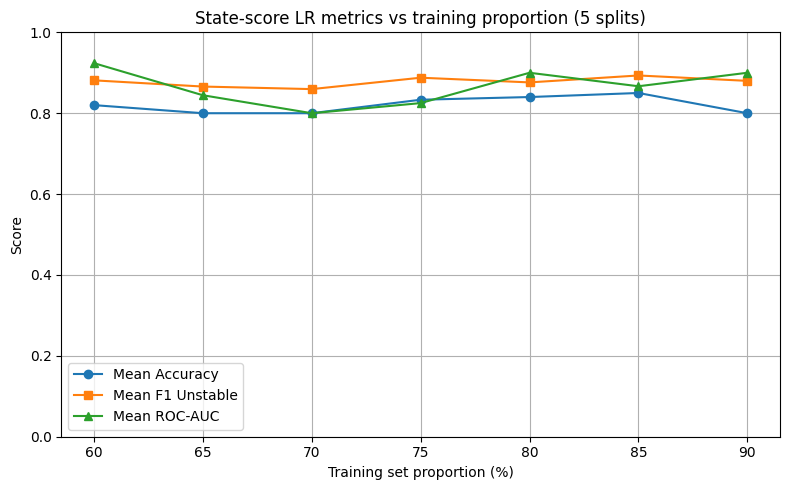

Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_10.png


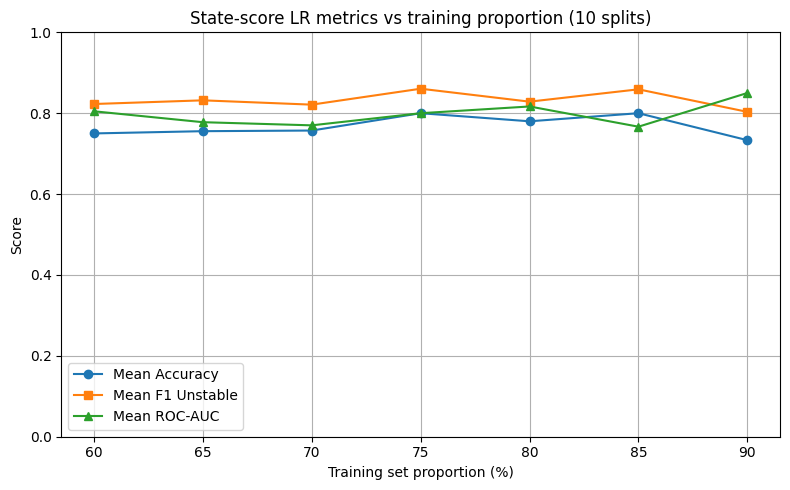

Saved: output_marker_state_score/lr_state_score_train_size_cv_summary_100.png


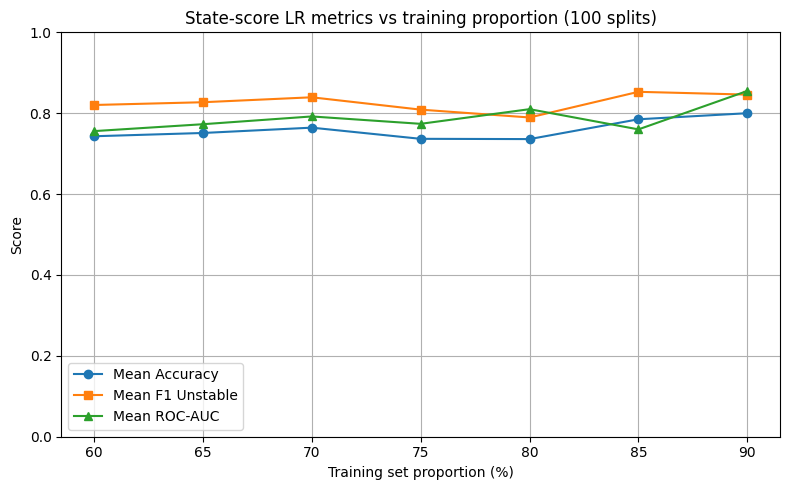

In [8]:
def plot_summary(summary: pd.DataFrame, n_splits: int) -> None:
    df = summary.sort_values("train_percent")
    x = df["train_percent"].to_numpy()

    series = [
        ("mean_accuracy", "std_accuracy", "Mean Accuracy", "o"),
        ("mean_f1_unstable", "std_f1_unstable", "Mean F1 Unstable", "s"),
        ("mean_roc_auc", "std_roc_auc", "Mean ROC-AUC", "^"),
    ]

    plt.figure(figsize=(8, 5))
    for mean_col, std_col, label, marker in series:
        mean_values = df[mean_col].to_numpy(dtype=float)
        std_values = df[std_col].fillna(0).to_numpy(dtype=float)
        lower = np.clip(mean_values - std_values, 0, 1)
        upper = np.clip(mean_values + std_values, 0, 1)

        line = plt.plot(x, mean_values, marker=marker, label=f"{label} mean")[0]
        plt.fill_between(
            x,
            lower,
            upper,
            color=line.get_color(),
            alpha=0.15,
            linewidth=0,
            label=f"{label} ± SD",
        )

    plt.xlabel("Training set proportion (%)")
    plt.ylabel("Score")
    plt.title(f"State-score LR metrics with SD vs training proportion ({n_splits} splits)")
    plt.xticks(df["train_percent"])
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_png = OUT_DIR / f"lr_state_score_train_size_cv_summary_{n_splits}_with_std.png"
    plt.savefig(out_png, dpi=300)
    print(f"Saved: {out_png}")
    plt.show()


for n_splits, output in cv_outputs.items():
    plot_summary(output["summary"], n_splits=n_splits)


## Final model and existing unknown prediction

This optional section fits state-score parameters and the classifier on all labeled samples, then predicts the existing unknown feature CSV files if they are present.

In [9]:
state_params_final, marker_report_final = fit_state_score_params(
    X_pb,
    STATE_MARKERS,
    min_genes=MIN_GENES_PER_STATE,
)
X_train_final = make_state_score_features(X_basic, X_pb, state_params_final)

final_model = build_lr_model()
final_model.fit(X_train_final, y)

coef_df = pd.DataFrame({
    "feature": X_train_final.columns,
    "coefficient": final_model.named_steps["clf"].coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_df.to_csv(OUT_DIR / "final_lr_state_score_feature_coefficients.csv", index=False)

print("Final training feature shape:", X_train_final.shape)
display(coef_df.head(20))

if X_BASIC_UNKNOWN_PATH.exists() and X_PB_UNKNOWN_PATH.exists():
    X_basic_unknown = pd.read_csv(X_BASIC_UNKNOWN_PATH, index_col=0)
    X_pb_unknown = pd.read_csv(X_PB_UNKNOWN_PATH, index_col=0)

    common_unknown = X_basic_unknown.index.intersection(X_pb_unknown.index)
    X_basic_unknown = X_basic_unknown.loc[common_unknown].sort_index()
    X_pb_unknown = X_pb_unknown.loc[common_unknown].sort_index()

    X_unknown_final = make_state_score_features(X_basic_unknown, X_pb_unknown, state_params_final)
    X_unknown_final = X_unknown_final.reindex(columns=X_train_final.columns, fill_value=0)
    X_unknown_final.to_csv(OUT_DIR / "X_unknown_combined_basic_plus_state_scores.csv")

    prob_unstable = final_model.predict_proba(X_unknown_final)[:, 1]
    pred = pd.DataFrame({
        "sample_id": X_unknown_final.index,
        "prob_unstable": prob_unstable,
    })
    pred["pred_label_threshold_0.5"] = np.where(pred["prob_unstable"] >= 0.5, "unstable", "stable")
    pred["pred_label_threshold_0.6"] = np.where(pred["prob_unstable"] >= 0.6, "unstable", "stable")
    pred["pred_3class"] = pred["prob_unstable"].apply(assign_3class)
    pred = pred.sort_values("prob_unstable", ascending=False)
    pred.to_csv(OUT_DIR / "final_prediction_unstable_probability_state_score.csv", index=False)

    print("Unknown prediction saved:", OUT_DIR / "final_prediction_unstable_probability_state_score.csv")
    display(pred)
else:
    print("Skip unknown prediction: unknown feature CSV files were not found.")

Final training feature shape: (23, 24)


,feature,coefficient,abs_coefficient
2,prop__Endothelial cell,-0.881226,0.881226
9,prop__Neutrophil,0.789689,0.789689
5,prop__Macrophage,-0.747708,0.747708
16,score__Macrophage_matrix_degradation,-0.675536,0.675536
7,prop__Monocyte,0.545635,0.545635
1,prop__Dendritic cell,-0.506415,0.506415
17,score__SMC_contractile,-0.487827,0.487827
20,score__Endothelial_quiescent,-0.364891,0.364891
22,score__Fibroblast_ECM_remodeling,-0.360665,0.360665
21,score__Endothelial_activation_angiogenesis,0.296313,0.296313


Unknown prediction saved: output_marker_state_score/final_prediction_unstable_probability_state_score.csv


,sample_id,prob_unstable,pred_label_threshold_0.5,pred_label_threshold_0.6,pred_3class
21,GSE143921_5,1.000000e+00,unstable,unstable,high-confidence unstable
22,GSE143921_6,1.000000e+00,unstable,unstable,high-confidence unstable
20,GSE143921_4,1.000000e+00,unstable,unstable,high-confidence unstable
48,GSE166676_6,1.000000e+00,unstable,unstable,high-confidence unstable
19,GSE143921_3,1.000000e+00,unstable,unstable,high-confidence unstable
...,...,...,...,...,...
122,GSE247238_14,9.115276e-07,stable,stable,non-unstable
119,GSE247238_11,8.157345e-08,stable,stable,non-unstable
128,GSE247238_2,6.557693e-09,stable,stable,non-unstable
132,GSE247238_6,3.779723e-09,stable,stable,non-unstable


## Output files

Main outputs are written under `output_marker_state_score/`, leaving the original notebook and original `output_marker/` results unchanged.

In [10]:
for path in sorted(OUT_DIR.glob("*")):
    print(path)

output_marker_state_score/X_combined_basic_plus_state_scores.csv
output_marker_state_score/X_state_scores.csv
output_marker_state_score/X_unknown_combined_basic_plus_state_scores.csv
output_marker_state_score/final_lr_state_score_feature_coefficients.csv
output_marker_state_score/final_prediction_unstable_probability_state_score.csv
output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_10.csv
output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_100.csv
output_marker_state_score/lr_state_score_train_size_cv_all_fold_predictions_5.csv
output_marker_state_score/lr_state_score_train_size_cv_summary_10.csv
output_marker_state_score/lr_state_score_train_size_cv_summary_10.png
output_marker_state_score/lr_state_score_train_size_cv_summary_100.csv
output_marker_state_score/lr_state_score_train_size_cv_summary_100.png
output_marker_state_score/lr_state_score_train_size_cv_summary_5.csv
output_marker_state_score/lr_state_score_train_size_cv_summary_5.